In [2]:
"""
============================================================
INFOTACT INTERNSHIP – PROJECT 2
Supply Chain Analytics: Demand Forecasting & Anomaly Detection
------------------------------------------------------------
WEEK 1: Time-Series Preprocessing & Decomposition
============================================================
Datasets Used:
  1. sales_data.csv            → primary (76,000 rows, 5 categories, daily)
  2. retail_store_inventory.csv → secondary (73,100 rows, Demand Forecast col)
  3. demand_forecasting_dataset.csv → supporting (4,999 rows, future_demand)
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid")

In [10]:
# 1. Load all 3 files
files = [
    "Customers_A_ID12346-14312.xlsx",
    "Customers_B_ID14314-16283.xlsx",
    "Customers_C_ID16284-18287.xlsx",
]
dfs = [pd.read_excel(f) for f in files]


In [5]:
# 2. Combine into one DataFrame
df = pd.concat(dfs, ignore_index=True)
print("Combined shape:", df.shape)


Combined shape: (406829, 8)


In [6]:
# 3. Basic info
print("\nMissing values:\n", df.isnull().sum())
print("\nSummary statistics:\n", df.describe())



Missing values:
 InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Summary statistics:
             Quantity                    InvoiceDate      UnitPrice  \
count  406829.000000                         406829  406829.000000   
mean       12.061303  2011-07-13 05:50:35.511038208       3.460471   
min    -80995.000000            2010-12-01 08:26:00       0.000000   
25%         2.000000            2011-04-07 18:09:00       1.250000   
50%         5.000000            2011-08-01 11:23:00       1.950000   
75%        12.000000            2011-10-21 08:40:00       3.750000   
max     80995.000000            2014-11-12 08:26:00   38970.000000   
std       248.693370                            NaN      69.315162   

          CustomerID  
count  406829.000000  
mean    15287.690570  
min     12346.000000  
25%     13953.000000  
50%     15152.000000  
75%     16791.000000  
max     18287.00000

In [7]:
# 4. Add Revenue column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [8]:
# 5. Basic aggregations
top_countries = df["Country"].value_counts().head(10)
revenue_by_country = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

print("\nTop 10 countries by order count:\n", top_countries)
print("\nTop 10 countries by revenue:\n", revenue_by_country)


Top 10 countries by order count:
 Country
United Kingdom    361878
Germany             9495
France              8491
EIRE                7485
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         1877
Portugal            1480
Australia           1259
Name: count, dtype: int64

Top 10 countries by revenue:
 Country
United Kingdom    6767873.394
Netherlands        284661.540
EIRE               250285.220
Germany            221698.210
France             196712.840
Australia          137077.270
Switzerland         55739.400
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64


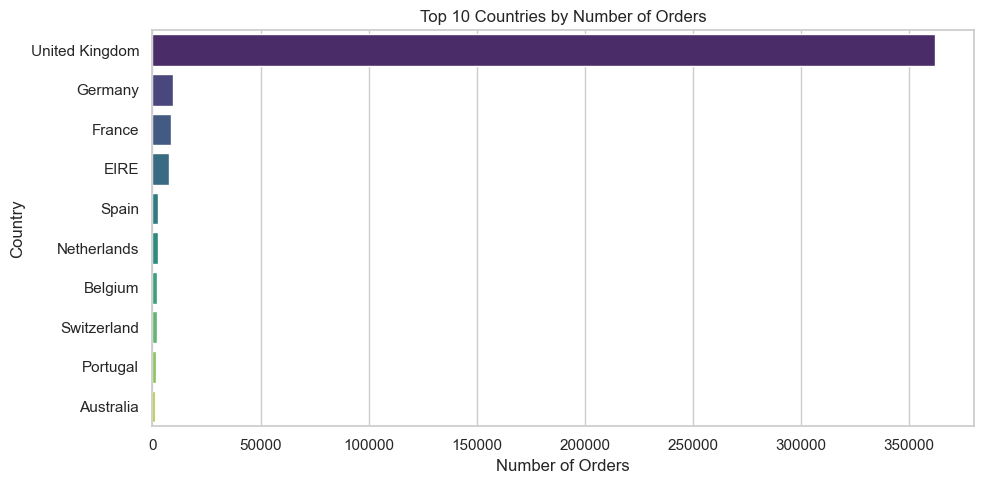

In [20]:

# ------------------------------------------------------------------
# Seaborn visualizations
# ------------------------------------------------------------------

# Plot 1: Top 10 countries by number of orders (bar chart)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index,
            palette="viridis", legend=False)
plt.title("Top 10 Countries by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("top_countries_orders.png", dpi=150)
plt.show()

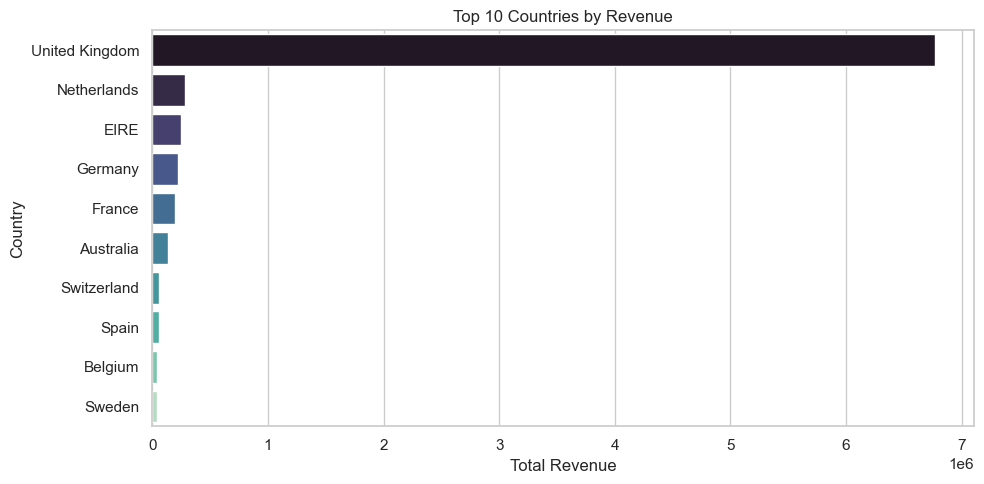

In [19]:
# Plot 2: Top 10 countries by revenue (bar chart)
plt.figure(figsize=(10, 5))
sns.barplot(x=revenue_by_country.values, y=revenue_by_country.index, hue=revenue_by_country.index,
            palette="mako", legend=False)
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("top_countries_revenue.png", dpi=150)
plt.show()

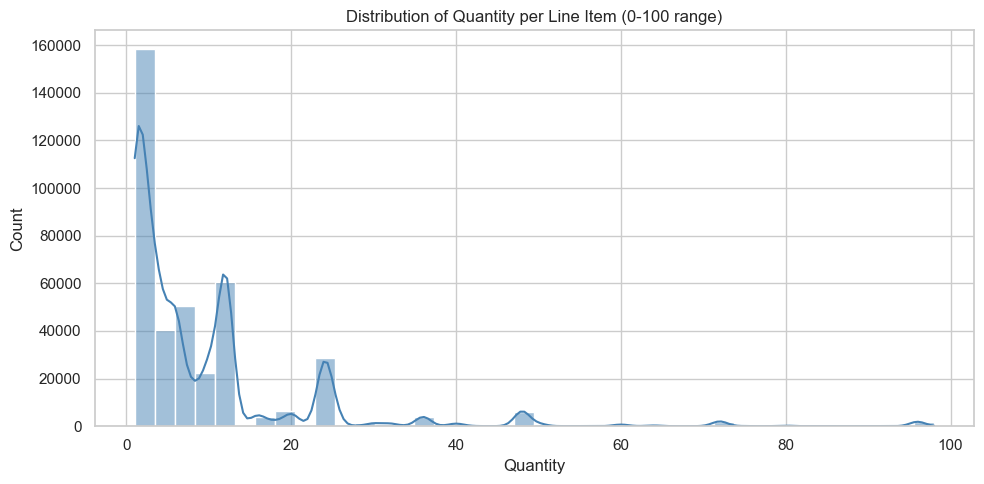

In [21]:
# Plot 3: Distribution of Quantity (histogram), clipped to remove extreme outliers for readability
plt.figure(figsize=(10, 5))
sns.histplot(df[(df["Quantity"] > 0) & (df["Quantity"] < 100)]["Quantity"], bins=40, kde=True, color="steelblue")
plt.title("Distribution of Quantity per Line Item (0-100 range)")
plt.xlabel("Quantity")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("quantity_distribution.png", dpi=150)
plt.show()

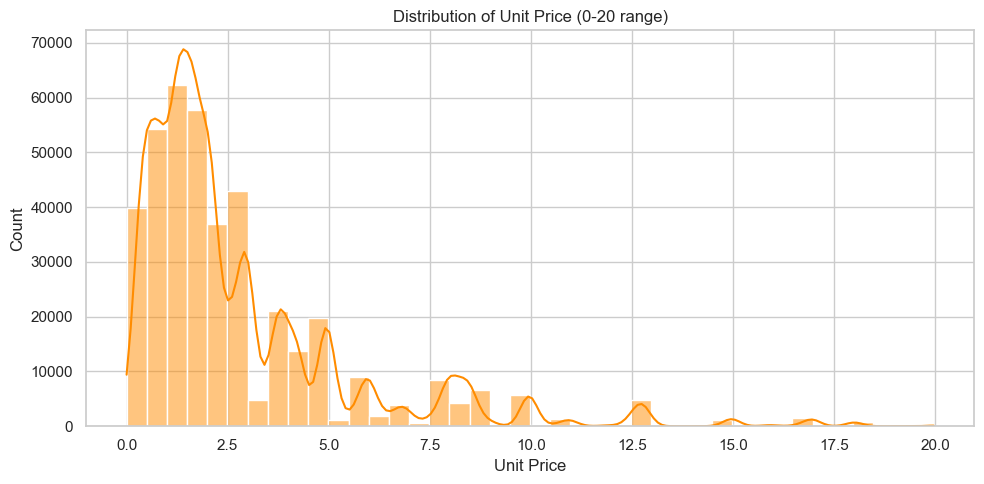

In [22]:
# Plot 4: Distribution of UnitPrice (histogram), clipped for readability
plt.figure(figsize=(10, 5))
sns.histplot(df[(df["UnitPrice"] > 0) & (df["UnitPrice"] < 20)]["UnitPrice"], bins=40, kde=True, color="darkorange")
plt.title("Distribution of Unit Price (0-20 range)")
plt.xlabel("Unit Price")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("unitprice_distribution.png", dpi=150)
plt.show()


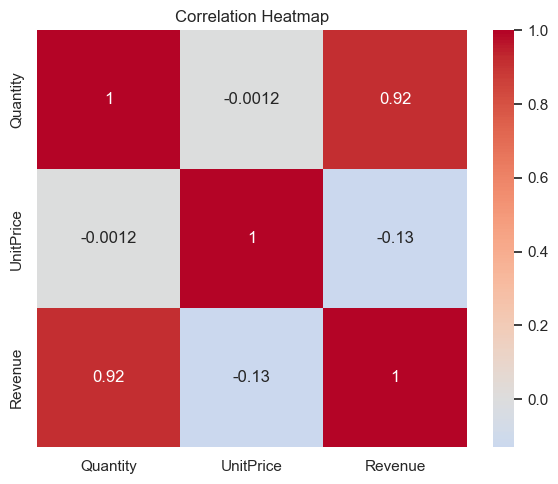

In [23]:
# Plot 5: Correlation heatmap of numeric columns
plt.figure(figsize=(6, 5))
numeric_cols = df[["Quantity", "UnitPrice", "Revenue"]]
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

In [18]:

print("\nAll plots saved: top_countries_orders.png, top_countries_revenue.png, "
      "quantity_distribution.png, unitprice_distribution.png, correlation_heatmap.png")


All plots saved: top_countries_orders.png, top_countries_revenue.png, quantity_distribution.png, unitprice_distribution.png, correlation_heatmap.png
